In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
connection = sqlite3.connect('Churn analysis data')
cursor = connection.cursor()

In [8]:
print("Duplicate rows:", raw.duplicated().sum())
print("Missing values:\n", raw.isnull().sum()[raw.isnull().sum() > 0])
print("\nContract labels:\n", raw["Contract"].value_counts())
print("\nPaymentMethod labels:\n", raw["PaymentMethod"].value_counts())
print("\nMonthlyCharges sample (some have $):\n", raw["MonthlyCharges"].head())

Duplicate rows: 5
Missing values:
 TotalCharges    126
dtype: int64

Contract labels:
 Contract
Month-to-month    3226
Two year          1697
One year          1473
month to month     652
Name: count, dtype: int64

PaymentMethod labels:
 PaymentMethod
Electronic check              2079
Mailed check                  1410
Bank transfer (automatic)     1349
Credit card (automatic)       1329
Electronic check               288
Mailed check                   203
Bank transfer (automatic)      197
Credit card (automatic)        193
Name: count, dtype: int64

MonthlyCharges sample (some have $):
 0    $29.85
1     56.95
2     53.85
3      42.3
4      70.7
Name: MonthlyCharges, dtype: object


In [9]:
df = raw.drop_duplicates().copy()                                  # 1. remove duplicate rows

df["PaymentMethod"] = df["PaymentMethod"].str.strip()              # 2. remove extra spaces
df["Contract"] = df["Contract"].replace({"month to month": "Month-to-month"})   # 3. same label everywhere

df["MonthlyCharges"] = df["MonthlyCharges"].astype(str).str.replace("$", "", regex=False).astype(float)  # 4. text to number

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"])   # 5. fill missing = tenure x monthly

df.loc[df["InternetService"] == "No", "StreamingTV"] = "No internet service"    # 6. fix contradictions
df.loc[df["PhoneService"] == "No", "MultipleLines"] = "No phone service"

print("Rows before:", len(raw), "-> after:", len(df))

Rows before: 7048 -> after: 7043


In [10]:
print("Duplicates:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print(df["Contract"].value_counts())
df.dtypes[["MonthlyCharges", "TotalCharges"]]

Duplicates: 0
Missing values: 0
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


,0
MonthlyCharges,float64
TotalCharges,float64


In [11]:
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)     # 1 = left, 0 = stayed

df["tenure_band"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 100],
                           labels=["0-6 Months", "6-12 Months", "12+ Months"])

In [12]:
total = len(df)
churned = df["churn_flag"].sum()
print("Total customers:", total)
print("Churned customers:", churned)
print("Churn rate: {:.2f}%".format(churned / total * 100))

Total customers: 7043
Churned customers: 1869
Churn rate: 26.54%


Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn_flag, dtype: float64 



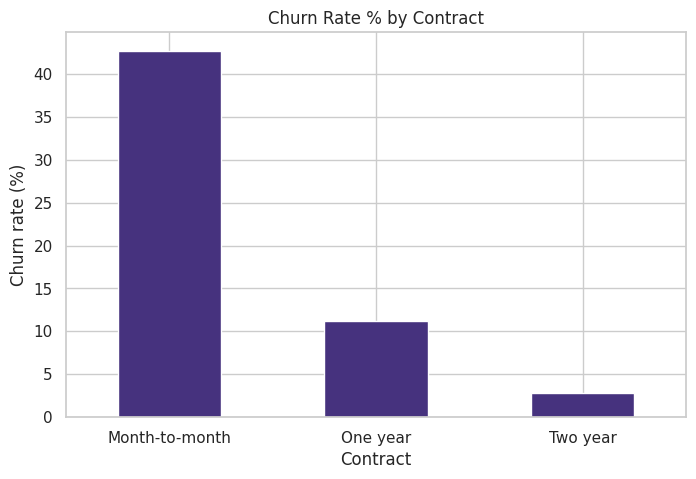

tenure_band
0-6 Months     52.94
6-12 Months    35.89
12+ Months     17.13
Name: churn_flag, dtype: float64 



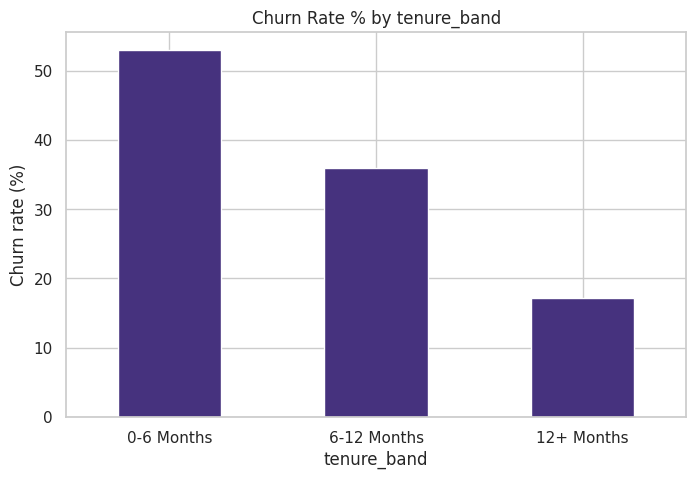

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: churn_flag, dtype: float64 



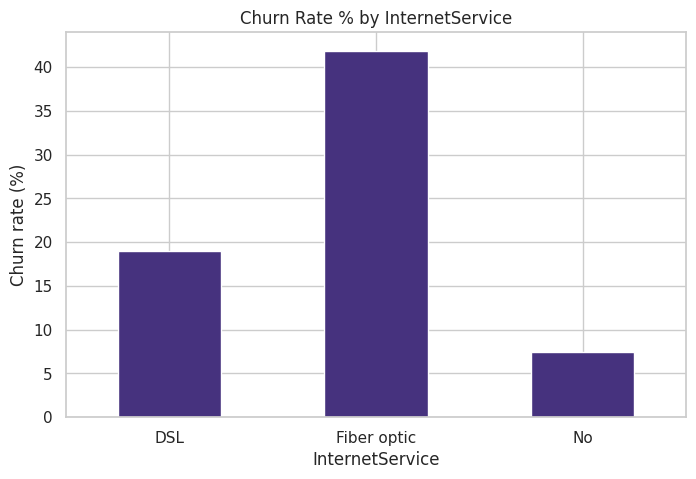

PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: churn_flag, dtype: float64 



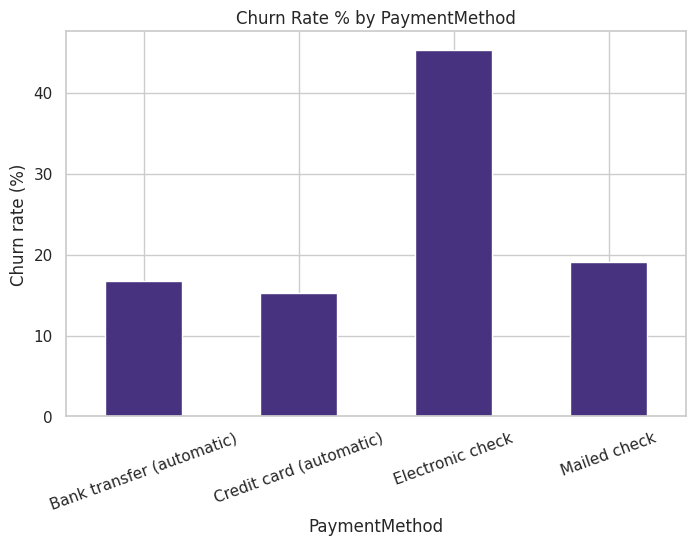

In [13]:
for col in ["Contract", "tenure_band", "InternetService", "PaymentMethod"]:
    rate = df.groupby(col)["churn_flag"].mean() * 100
    print(rate.round(2), "\n")
    rate.plot(kind="bar", title="Churn Rate % by " + col, ylabel="Churn rate (%)")
    plt.xticks(rotation=0 if col != "PaymentMethod" else 20)
    plt.show()

In [14]:
# Share of all churn coming from month-to-month customers
churned_by_contract = df[df["churn_flag"] == 1]["Contract"].value_counts()
print(churned_by_contract)
print("Month-to-month share of churn: {:.1f}%".format(
      churned_by_contract["Month-to-month"] / churned_by_contract.sum() * 100))

# Do churned customers pay more?
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))

df.to_csv("Churn_cleaned.csv", index=False)

Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64
Month-to-month share of churn: 88.6%
Churn
No     61.27
Yes    74.42
Name: MonthlyCharges, dtype: float64
